# Analysis results to compare Mediapipe heavy and Yolo26n

## Tools

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

## Precision analysis

To perform the accuracy analysis, we used two metrics, OKS and PCK, on ​​the COCO dataset.

* Object Keypoint Similarity (OKS):

It penalizes the error, taking into account the size of the person in the image and how "difficult" it is to label each specific joint.

$$OKS = \frac{\sum_i \exp(\frac{-d_i^2}{2s^2k_i^2}) \delta(v_i > 0)}{\sum_i \delta(v_i > 0)}$$

$d_i$: This is the Euclidean distance between the predicted point ($x_p, y_p$) and the actual point ($x_g, y_g$). It is calculated as: $\sqrt{(x_p-x_g)^2 + (y_p-y_g)^2}$. 

$s$: This is the person's scale. It is usually defined as the square root of the area of ​​the bordering box ($s = \sqrt{width \times height}$). 

$k_i$: Constant per joint that controls the exponential fall (the variation of human scorers). $k_i = σ_i^2=E[\frac{d_i^2}{s^2}]$

$v_i$: This is the visibility of the point in the Ground Truth ($v=0$: unlabeled, $v=1$: occluded, $v=2$: visible). The function $\delta(v_i > 0)$ simply indicates that we only sum the points that exist in the actual dataset.

$\delta()$: Function that equals 1 if the condition is true, 0 if not.


For more information visit the coco dataset web: https://cocodataset.org/#keypoints-eval.

* Percentage of correct key points (PCK):

PCK measures the percentage of key points that the model has predicted "correctly." A point is considered correct if the difference between the prediction and the actual value is below a specific threshold.

$$PCK = \frac{1}{N} \sum_{i=1}^{N} \delta \left( \frac{d_i}{d_{norm}} \le T \right)$$

$N$: Total number of key points (in your case, 12).

$\mathbf{p}_i$: Coordinates $(x, y)$ of the predicted point.

$\mathbf{g}_i$: Coordinates $(x, y)$ of the actual point (Ground Truth).

$d_i$: : Euclidean distance. 

$d_{norm}$: Normalization distance (e.g., size of the diagonal bounding box, or distance from the shoulder to the opposite hip).

$T$: Tolerance threshold (e.g., $0.2$, which means 20% of $d_{norm}$).

In [ ]:
results_oks_pck_path = Path.cwd().parent.parent / 'results' / 'phase_1' / 'results_oks_pck.csv'
results_oks_pck_data = pd.read_csv(str(results_oks_pck_path))

# Conteo de nulos por columna
print("----------Total nulos----------\n", results_oks_pck_data.isna().sum())

# Average percentage of null values ​​per column
print("----------Average percentage of null values ​​per column----------\n", results_oks_pck_data.isna().mean() * 100)

# NaN values in distance by model_name
print("----------NaN values in distance by model_name----------\n", results_oks_pck_data.groupby('model_name')['distance'].apply(lambda x: x.isna().sum()))

# Total empty spaces
print("----------Total empty spaces dataframe----------\n", (results_oks_pck_data == "").sum())

----------Total nulos----------
 image_id          0
model_name        0
keypoint_name     0
visibility        0
distance         96
oks_score         0
pck               0
dtype: int64
----------Average percentage of null values ​​per column----------
 image_id         0.000000
model_name       0.000000
keypoint_name    0.000000
visibility       0.000000
distance         4.878049
oks_score        0.000000
pck              0.000000
dtype: float64
----------NaN values in distance by model_name----------
 model_name
mediapipe    84
yolo         12
Name: distance, dtype: int64
----------Total empty spaces dataframe----------
 image_id         0
model_name       0
keypoint_name    0
visibility       0
distance         0
oks_score        0
pck              0
dtype: int64


In the previous block, we can observe 96 entries with NA values in the distance attribute out of a total of 1,968 rows. Furthermore, a closer analysis reveals that MediaPipe was unable to detect 84 out of these 96 entries.

In the next section, we will evaluate the severity of this issue and determine if the images are particularly complex.

Image_id with distance NA's Yolo: [560880]
Image_id with distance NA's Mediapipe: [492758   9772 370711 289960 560880 317433 408120]
----------OKS and PCK score Yolo images [492758   9772 370711 289960 317433 408120]----------
    - OKS mean: 0.8373017939858403
    - PCK mean: 0.7222222222222222
----------Images ids with distances NA's----------
 [492758   9772 370711 289960 560880 317433 408120]


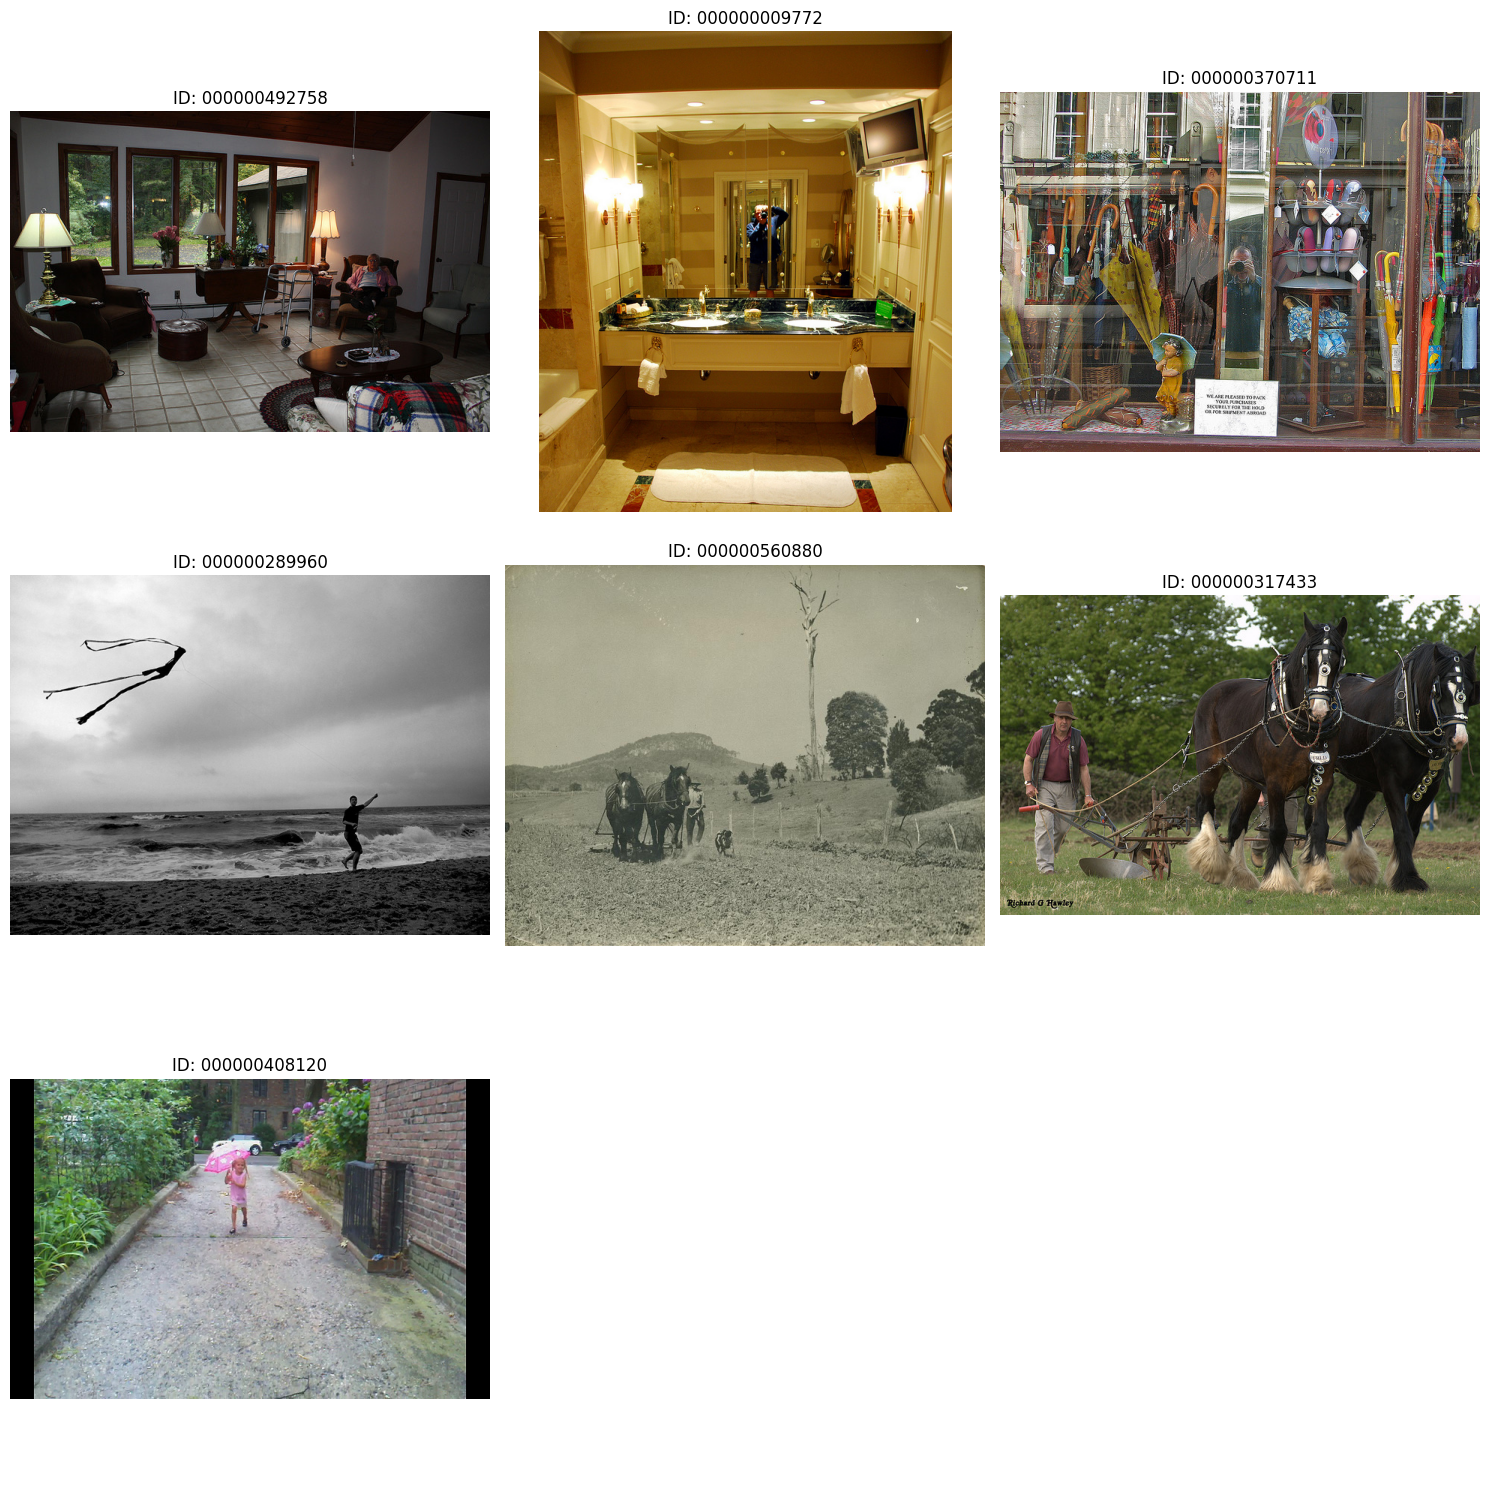

In [ ]:
# Show the images that Yolo and Mediapipe cant detect all the keypoints
results_yolo_distance_na = results_oks_pck_data[(results_oks_pck_data['model_name'] == 'yolo') & (results_oks_pck_data['distance'].isna())]
results_mediapipe_distance_na = results_oks_pck_data[(results_oks_pck_data['model_name'] == 'mediapipe') & (results_oks_pck_data['distance'].isna())]

print("Image_id with distance NA's Yolo:", results_yolo_distance_na['image_id'].unique())
print("Image_id with distance NA's Mediapipe:", results_mediapipe_distance_na['image_id'].unique())

# Calculation of OKS and PCK over the images that Yolo can detect but not Mediapipe
results_image_id_yolo_distance_na_notinmediapipe = results_mediapipe_distance_na[~results_mediapipe_distance_na['image_id'].isin(results_yolo_distance_na['image_id'].unique())]['image_id'].unique()
results_yolo_distance_na_notinmediapipe = results_oks_pck_data[(results_oks_pck_data['model_name'] == 'yolo') & (results_oks_pck_data['image_id'].isin(results_image_id_yolo_distance_na_notinmediapipe))]
results_yolo_distance_na_notinmediapipe_oks = results_yolo_distance_na_notinmediapipe['oks_score'].mean()
results_yolo_distance_na_notinmediapipe_pck = results_yolo_distance_na_notinmediapipe['pck'].mean()

print(f"----------OKS and PCK score Yolo images {results_image_id_yolo_distance_na_notinmediapipe}----------")
print(f"    - OKS mean: {results_yolo_distance_na_notinmediapipe_oks}")
print(f"    - PCK mean: {results_yolo_distance_na_notinmediapipe_pck}")



results_distance_na = results_oks_pck_data[results_oks_pck_data['distance'].isna()]
images_ids_distance_na = results_distance_na['image_id'].unique()
print("----------Images ids with distances NA's----------\n", images_ids_distance_na)

# Find images script
path_coco_images = Path.cwd().parent.parent / 'data' / 'coco_dataset' / 'images_coco'
images = []
for image_id in images_ids_distance_na:
    glob_path = path_coco_images.glob(f'*{image_id}*.jpg')
    file = next(glob_path, None) 
    if file:
        images.append(file)

# Show images script
cols = 3
rows = (len(images) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

axes = axes.flatten()

for i, img_path in enumerate(images):
    img = mpimg.imread(str(img_path))
    axes[i].imshow(img)
    axes[i].set_title(f"ID: {img_path.stem}")
    axes[i].axis('off') 

for j in range(len(images), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


The plot above illustrates the image quality. Some of these images are of very poor quality, making it difficult even for a human to distinguish a person's figure. As we can see in the previous block, the only image for which YOLO is unable to detect all keypoints is image ID 560880.

If we analyze the OKS scores and PCK values of the images that YOLO can detect but MediaPipe cannot, we can see that the accuracy is not perfect, with scores of OKS = 0.8373 and PCK = 0.7222.

In the next section, we will compare the OKS and PCK accuracy across the entire dataset to draw more robust conclusions.

In [ ]:
# Full precision score
mediapipe_oks = results_oks_pck_data[results_oks_pck_data['model_name'] == 'mediapipe']['oks_score'].mean()
mediapipe_pck = results_oks_pck_data[results_oks_pck_data['model_name'] == 'mediapipe']['pck'].mean()

yolo_oks = results_oks_pck_data[results_oks_pck_data['model_name'] == 'yolo']['oks_score'].mean()
yolo_pck = results_oks_pck_data[results_oks_pck_data['model_name'] == 'yolo']['pck'].mean()

print("----------Precision score comparison MediaPipe heavy vs Yolo26n----------")
print(f"    Mediapipe\n        - OKS Score = {mediapipe_oks}\n        - PCK Score = {mediapipe_pck}")
print(f"    Yolo26n\n        - OKS Score = {yolo_oks}\n        - PCK Score = {yolo_pck}")

# Precision score excluding NAs values 
results_oks_pck_data_nonas = results_oks_pck_data.dropna()

mediapipe_oks_nonas = results_oks_pck_data_nonas[results_oks_pck_data_nonas['model_name'] == 'mediapipe']['oks_score'].mean()
mediapipe_pck_nonas = results_oks_pck_data_nonas[results_oks_pck_data_nonas['model_name'] == 'mediapipe']['pck'].mean()

yolo_oks_nonas = results_oks_pck_data_nonas[results_oks_pck_data_nonas['model_name'] == 'yolo']['oks_score'].mean()
yolo_pck_nonas = results_oks_pck_data_nonas[results_oks_pck_data_nonas['model_name'] == 'yolo']['pck'].mean()

print("----------Precision score excluding NAs values comparison MediaPipe heavy vs Yolo26n----------")
print(f"    Mediapipe\n        - OKS Score = {mediapipe_oks_nonas}\n        - PCK Score = {mediapipe_pck_nonas}")
print(f"    Yolo26n\n        - OKS Score = {yolo_oks_nonas}\n        - PCK Score = {yolo_pck_nonas}")



----------Precision score comparison MediaPipe heavy vs Yolo26n----------
    Mediapipe
        - OKS Score = 0.7991407279824524
        - PCK Score = 0.8384146341463414
    Yolo26n
        - OKS Score = 0.9357224521735483
        - PCK Score = 0.899390243902439
----------Precision score excluding NAs values comparison MediaPipe heavy vs Yolo26n----------
    Mediapipe
        - OKS Score = 0.8737271959274812
        - PCK Score = 0.9166666666666666
    Yolo26n
        - OKS Score = 0.947274581212728
        - PCK Score = 0.9104938271604939


If we compare the results for MediaPipe and Yolo we can see that MediaPipe is less precise. This is more obvious when we compare the results without include the 'NA' (Not Available). The OKS score including the 'NA' distances are in MediaPipe 0.7991 against the 0.9357 score of the Yolo26n model.

This is slightly less noticeable when we compare the same factors but excluding the 'NA' distances. In this case the OKS score of MediaPipe is 0.8737 and OKS score of Yolo26n is 0.9473.

These data suggest that Mediapipe heavy version is less precise than Yolo26n when it process a very complex image. Nevertheless, for the system we will build it will not be complicated images, understanding them as images with distant subjects or images with multiple objects, so we can set as valid the second results, where the diference between Mediapipe and Yolo is not very big.

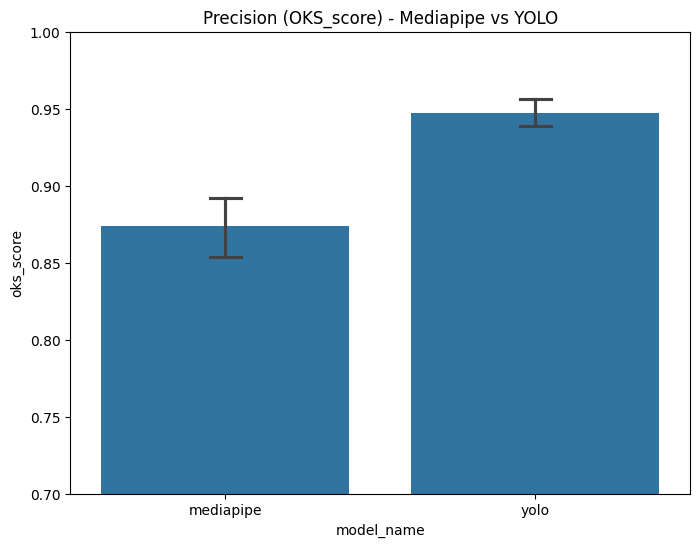

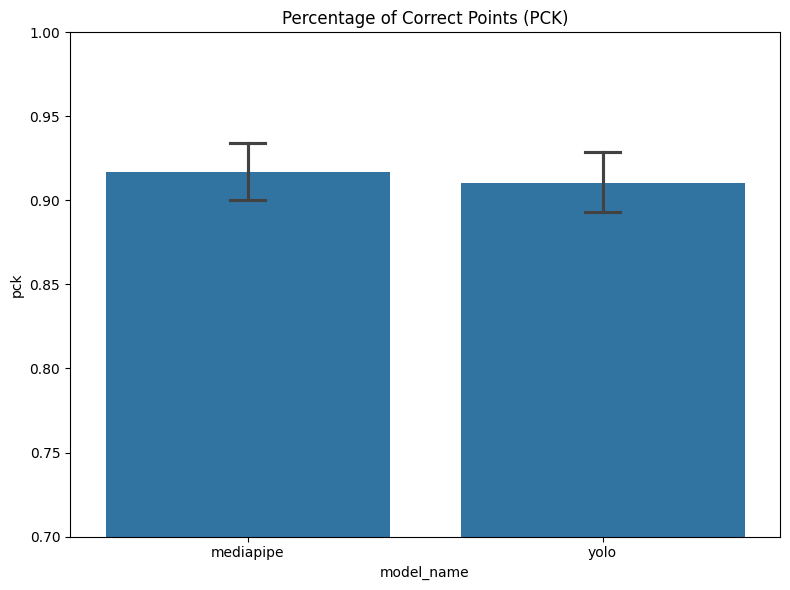

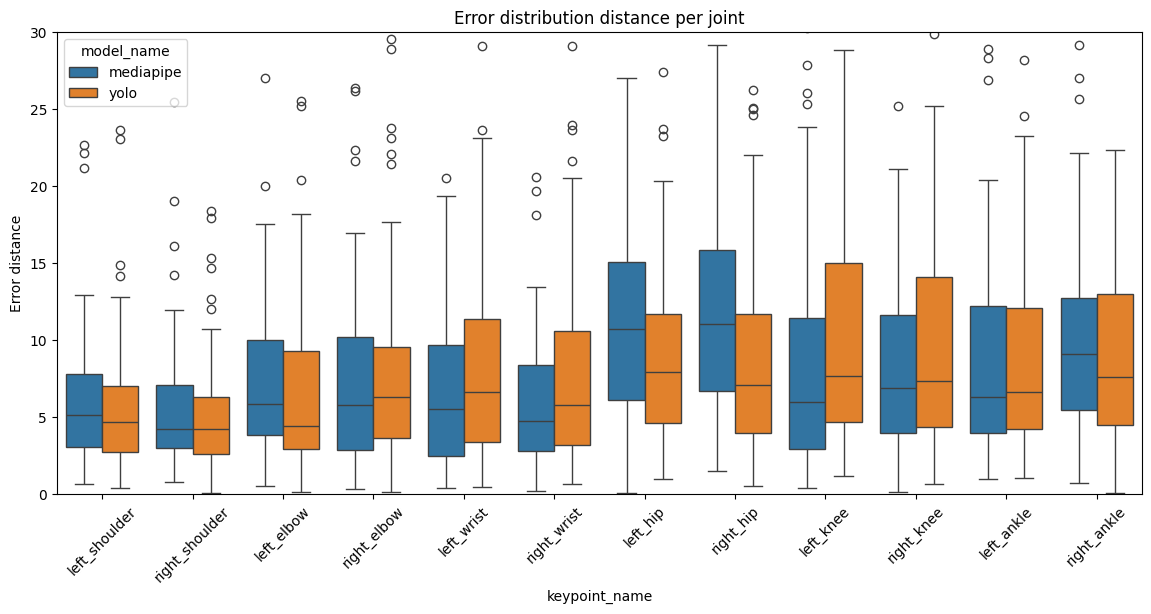

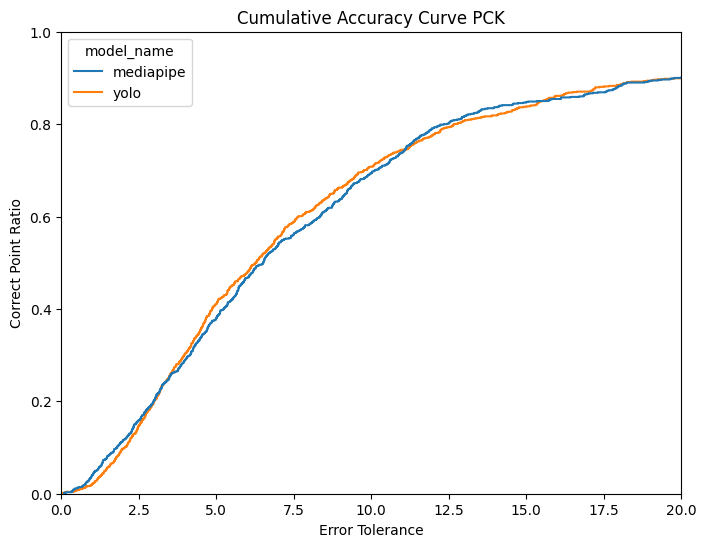

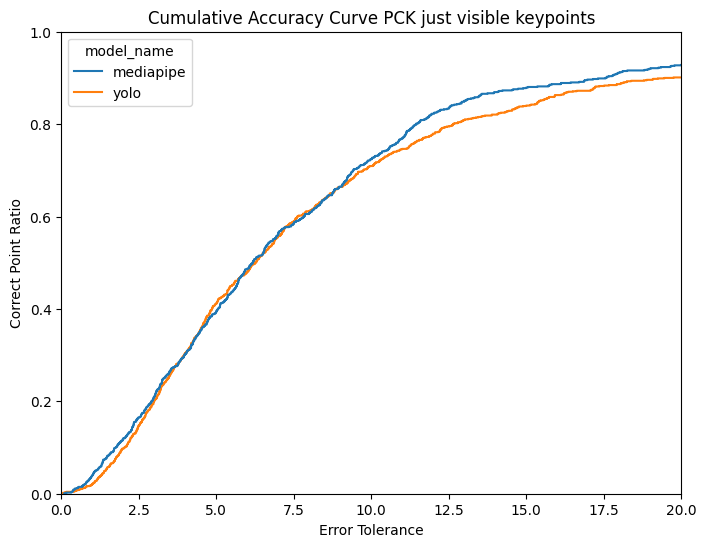

In [ ]:
# Plot 1: OKS score by model
plt.figure(figsize=(8, 6))
sns.barplot(data=results_oks_pck_data_nonas, x='model_name', y='oks_score', capsize=.1)
plt.title('Precision (OKS_score) - Mediapipe vs YOLO')
plt.ylim(0.7, 1.0)
plt.show()

# Plot 2: Success rate PCK by model
plt.figure(figsize=(8, 6))
sns.barplot(data=results_oks_pck_data_nonas, x='model_name', y='pck', capsize=.1)
plt.title('Percentage of Correct Points (PCK)')
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

# Plot 3: Error distribution distance per joint
plt.figure(figsize=(14, 6))
sns.boxplot(data=results_oks_pck_data_nonas, x='keypoint_name', y='distance', hue='model_name')
plt.title('Error distribution distance per joint')
plt.xticks(rotation=45)
plt.ylabel('Error distance')
plt.ylim(0, 30) 
plt.show()

# Plot 4: Cumulative Accuracy Curve PCK
plt.figure(figsize=(8, 6))
sns.ecdfplot(data=results_oks_pck_data_nonas, x='distance', hue='model_name')
plt.title('Cumulative Accuracy Curve PCK')
plt.xlabel('Error Tolerance')
plt.ylabel('Correct Point Ratio')
plt.xlim(0, 20)
plt.show()

# Plot 5: Cumulative Accuracy Curve PCK just valid
valid_data = results_oks_pck_data[results_oks_pck_data['visibility'] > 0]
plt.figure(figsize=(8, 6))
sns.ecdfplot(data=valid_data, x='distance', hue='model_name')
plt.title('Cumulative Accuracy Curve PCK just visible keypoints')
plt.xlabel('Error Tolerance')
plt.ylabel('Correct Point Ratio')
plt.xlim(0, 20)
plt.show()

## Performance analysis

We have collected performance data from video execution tests to compare the inference speeds of MediaPipe and YOLO. 

In the following results you can see the efficiency of both models executing sequentially.

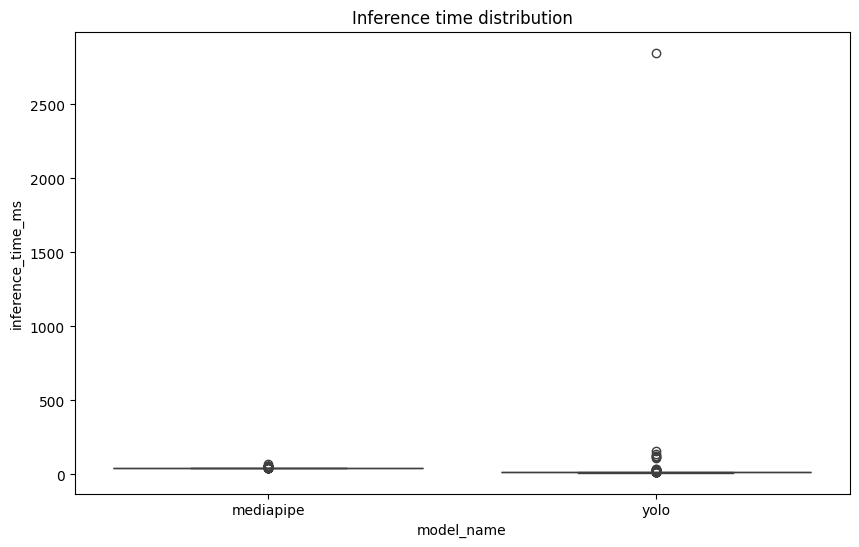

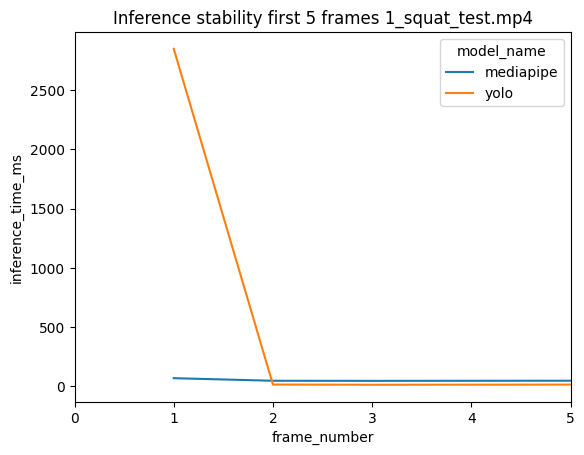

----------Mean fps by model----------
    - MediaPipe: 19.96743642914612
    - Yolo26n: 47.10259978204296


In [ ]:
results_inference_path = Path.cwd().parent.parent / 'results' / 'phase_1' / 'results_inference.csv'
results_inference_data = pd.read_csv(str(results_inference_path))

results_fps_path = Path.cwd().parent.parent / 'results' / 'phase_1' / 'results_fps.csv'
results_fps_data = pd.read_csv(str(results_fps_path))

# Plot 1: Inference time distribution by model
plt.figure(figsize=(10, 6))
sns.boxplot(data=results_inference_data, x='model_name', y='inference_time_ms')
plt.title('Inference time distribution')
plt.show()

# Plot 2: Inference stability first 20 frames 1_squat_test.mp4
df_video = results_inference_data[results_inference_data['video'] == '1_squat_test.mp4']
sns.lineplot(data=df_video, x='frame_number', y='inference_time_ms', hue='model_name')
plt.ylim()
plt.xlim(0,5)
plt.title('Inference stability first 5 frames 1_squat_test.mp4')
plt.show()

print("----------Mean tps by model----------")
print(f"    - MediaPipe: {results_fps_data[results_fps_data['model_name']=='mediapipe']['fps_process'].mean()}")
print(f"    - Yolo26n: {results_fps_data[results_fps_data['model_name']=='yolo']['fps_process'].mean()}")


As we can see above, YOLO spends more time processing the first frame. This is characteristic of how the model works and is interesting when compared to the rest of the frames. MediaPipe Heavy is slightly slower per frame than Yolo26n.

We can see this difference in more detail by looking at the FPS: Yolo26n reached 47.10 fps, which is superior to MediaPipe’s 19.97 fps. This is completely normal given that we are testing on a dedicated RTX 4060 GPU; on other hardware, the results would be different.

Now, let's see if these results lead to a higher computational cost.

In [ ]:
results_hardware_path = Path.cwd().parent.parent / 'results' / 'phase_1' / 'results_hardware.csv'
results_hardware_data = pd.read_csv(str(results_hardware_path))

print("----------Computational cost----------\n", results_hardware_data)

print("----------Average cpu power use----------")
print(f"    - MediaPipe: {results_hardware_data[results_hardware_data['model_name'] == 'mediapipe']['cpu_%'].mean()}")
print(f"    - Yolo26n: {results_hardware_data[results_hardware_data['model_name'] == 'yolo']['cpu_%'].mean()}")

----------Computational cost----------
    model_name              video      cpu_%    ram_gb      gpu_%   vram_gb
0   mediapipe   1_squat_test.mp4  13.960477  0.325148   0.000000  0.000000
1        yolo   1_squat_test.mp4  22.768169  0.972681  21.000000  0.193962
2   mediapipe   2_squat_test.mp4  11.464178  1.132559   0.000000  0.168571
3        yolo   2_squat_test.mp4  21.164178  0.874688  21.513514  0.193962
4   mediapipe   3_squat_test.mp4  11.732571  0.911319   0.000000  0.168571
5        yolo   3_squat_test.mp4  19.543682  0.632001  41.277778  0.193962
6   mediapipe   4_squat_test.mp4  16.707898  0.722398   0.000000  0.168571
7        yolo   4_squat_test.mp4  19.307898  0.582349  43.235294  0.193962
8   mediapipe   5_squat_test.mp4  18.087201  0.734977   0.000000  0.168571
9        yolo   5_squat_test.mp4  21.427941  0.591776  41.888889  0.193962
10  mediapipe   6_squat_test.mp4  11.643951  0.744143   0.000000  0.168571
11       yolo   6_squat_test.mp4  14.511693  0.599490  31.22

In the section above, we can see that MediaPipe doesn't use any GPU power. In the first instance—when YOLO hadn't been run yet—the VRAM usage was 0, proving that MediaPipe processes images on the CPU. We also noticed that YOLO's average CPU usage is higher than MediaPipe's.

Ultimately, MediaPipe Heavy performs very well given the low resources it needs. Since YOLO requires more powerful hardware, it isn't ideal for an app designed for the general public. Because of this, we'll be using MediaPipe as our main tool to detect poses for training our models and correcting bodyweight exercise form